# **Data Analytics in Commerce**

In [7]:
# Uploading libraries

library(tidyverse)
library(lubridate)
library(ggplot2)

In [8]:
# loading Data
orders <- read.csv('/content/olist_orders_dataset.csv')
items <- read.csv('/content/olist_order_items_dataset.csv')
products <- read.csv('/content/olist_products_dataset.csv')
customers <- read.csv('/content/olist_customers_dataset.csv')
reviews <- read.csv('/content/olist_order_reviews_dataset.csv')


In [9]:
#cleaning reviews
reviews_clean <- reviews %>%
  distinct(order_id, .keep_all = TRUE)

reviews_clean$review_comment_title[is.na(reviews_clean$review_comment_title)] <- "No comment"
reviews_clean$review_comment_message[is.na(reviews_clean$review_comment_message)] <- "No comment"

In [10]:
#Merging the dataset

df <- orders %>%
  inner_join(items, by = "order_id") %>%
  inner_join(products, by = "product_id") %>%
  inner_join(customers, by = "customer_id") %>%
  inner_join(reviews_clean, by = "order_id")

In [11]:
#checking data structure
head(orders)
str(orders)

head(items)
str(items)

head(products)
str(products)

head(customers)
str(customers)

head(reviews)
str(reviews)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
2,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
3,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
4,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
5,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
6,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00


'data.frame':	99441 obs. of  8 variables:
 $ order_id                     : chr  "e481f51cbdc54678b7cc49136f2d6af7" "53cdb2fc8bc7dce0b6741e2150273451" "47770eb9100c2d0c44946d9cf07ec65d" "949d5b44dbf5de918fe9c16f97b45f8a" ...
 $ customer_id                  : chr  "9ef432eb6251297304e76186b10a928d" "b0830fb4747a6c6d20dea0b8c802d7ef" "41ce2a54c0b03bf3443c3d931a367089" "f88197465ea7920adcdbec7375364d82" ...
 $ order_status                 : chr  "delivered" "delivered" "delivered" "delivered" ...
 $ order_purchase_timestamp     : chr  "2017-10-02 10:56:33" "2018-07-24 20:41:37" "2018-08-08 08:38:49" "2017-11-18 19:28:06" ...
 $ order_approved_at            : chr  "2017-10-02 11:07:15" "2018-07-26 03:24:27" "2018-08-08 08:55:23" "2017-11-18 19:45:59" ...
 $ order_delivered_carrier_date : chr  "2017-10-04 19:55:00" "2018-07-26 14:31:00" "2018-08-08 13:50:00" "2017-11-22 13:39:59" ...
 $ order_delivered_customer_date: chr  "2017-10-10 21:25:13" "2018-08-07 15:27:45" "2018-08-17 18:06:29" "20

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
2,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
3,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
4,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
5,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
6,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69


'data.frame':	112650 obs. of  7 variables:
 $ order_id           : chr  "00010242fe8c5a6d1ba2dd792cb16214" "00018f77f2f0320c557190d7a144bdd3" "000229ec398224ef6ca0657da4fc703e" "00024acbcdf0a6daa1e931b038114c75" ...
 $ order_item_id      : int  1 1 1 1 1 1 1 1 1 1 ...
 $ product_id         : chr  "4244733e06e7ecb4970a6e2683c13e61" "e5f2d52b802189ee658865ca93d83a8f" "c777355d18b72b67abbeef9df44fd0fd" "7634da152a4610f1595efa32f14722fc" ...
 $ seller_id          : chr  "48436dade18ac8b2bce089ec2a041202" "dd7ddc04e1b6c2c614352b383efe2d36" "5b51032eddd242adc84c38acab88f23d" "9d7a1d34a5052409006425275ba1c2b4" ...
 $ shipping_limit_date: chr  "2017-09-19 09:45:35" "2017-05-03 11:05:13" "2018-01-18 14:48:30" "2018-08-15 10:10:18" ...
 $ price              : num  58.9 239.9 199 13 199.9 ...
 $ freight_value      : num  13.3 19.9 17.9 12.8 18.1 ...


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40,287,1,225,16,10,14
2,3aa071139cb16b67ca9e5dea641aaa2f,artes,44,276,1,1000,30,18,20
3,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46,250,1,154,18,9,15
4,cef67bcfe19066a932b7673e239eb23d,bebes,27,261,1,371,26,4,26
5,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37,402,4,625,20,17,13
6,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,60,745,1,200,38,5,11


'data.frame':	32951 obs. of  9 variables:
 $ product_id                : chr  "1e9e8ef04dbcff4541ed26657ea517e5" "3aa071139cb16b67ca9e5dea641aaa2f" "96bd76ec8810374ed1b65e291975717f" "cef67bcfe19066a932b7673e239eb23d" ...
 $ product_category_name     : chr  "perfumaria" "artes" "esporte_lazer" "bebes" ...
 $ product_name_lenght       : int  40 44 46 27 37 60 56 56 57 36 ...
 $ product_description_lenght: int  287 276 250 261 402 745 1272 184 163 1156 ...
 $ product_photos_qty        : int  1 1 1 1 4 1 4 2 1 1 ...
 $ product_weight_g          : int  225 1000 154 371 625 200 18350 900 400 600 ...
 $ product_length_cm         : int  16 30 18 26 20 38 70 40 27 17 ...
 $ product_height_cm         : int  10 18 9 4 17 5 24 8 13 10 ...
 $ product_width_cm          : int  14 20 15 26 13 11 44 40 17 12 ...


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
,<chr>,<chr>,<int>,<chr>,<chr>
1,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
2,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
3,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
4,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
5,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
6,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC


'data.frame':	99441 obs. of  5 variables:
 $ customer_id             : chr  "06b8999e2fba1a1fbc88172c00ba8bc7" "18955e83d337fd6b2def6b18a428ac77" "4e7b3e00288586ebd08712fdd0374a03" "b2b6027bc5c5109e529d4dc6358b12c3" ...
 $ customer_unique_id      : chr  "861eff4711a542e4b93843c6dd7febb0" "290c77bc529b7ac935b93aa66c333dc3" "060e732b5b29e8181a18229c7b0b2b5e" "259dac757896d24d7702b9acbbff3f3c" ...
 $ customer_zip_code_prefix: int  14409 9790 1151 8775 13056 89254 4534 35182 81560 30575 ...
 $ customer_city           : chr  "franca" "sao bernardo do campo" "sao paulo" "mogi das cruzes" ...
 $ customer_state          : chr  "SP" "SP" "SP" "SP" ...


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,,,2018-01-18 00:00:00,2018-01-18 21:46:59
2,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,,,2018-03-10 00:00:00,2018-03-11 03:05:13
3,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,,,2018-02-17 00:00:00,2018-02-18 14:36:24
4,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
5,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa,2018-03-01 00:00:00,2018-03-02 10:26:53
6,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,,,2018-04-13 00:00:00,2018-04-16 00:39:37


'data.frame':	99224 obs. of  7 variables:
 $ review_id              : chr  "7bc2406110b926393aa56f80a40eba40" "80e641a11e56f04c1ad469d5645fdfde" "228ce5500dc1d8e020d8d1322874b6f0" "e64fb393e7b32834bb789ff8bb30750e" ...
 $ order_id               : chr  "73fc7af87114b39712e6da79b0a377eb" "a548910a1c6147796b98fdf73dbeba33" "f9e4b658b201a9f2ecdecbb34bed034b" "658677c97b385a9be170737859d3511b" ...
 $ review_score           : int  4 5 5 5 5 1 5 5 5 4 ...
 $ review_comment_title   : chr  "" "" "" "" ...
 $ review_comment_message : chr  "" "" "" "Recebi bem antes do prazo estipulado." ...
 $ review_creation_date   : chr  "2018-01-18 00:00:00" "2018-03-10 00:00:00" "2018-02-17 00:00:00" "2017-04-21 00:00:00" ...
 $ review_answer_timestamp: chr  "2018-01-18 21:46:59" "2018-03-11 03:05:13" "2018-02-18 14:36:24" "2017-04-21 22:02:06" ...


In [12]:
#check summary
summary(orders)
summary(items)
summary(products)
summary(customers)
summary(reviews)

   order_id         customer_id        order_status      
 Length:99441       Length:99441       Length:99441      
 Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character  
 order_purchase_timestamp order_approved_at  order_delivered_carrier_date
 Length:99441             Length:99441       Length:99441                
 Class :character         Class :character   Class :character            
 Mode  :character         Mode  :character   Mode  :character            
 order_delivered_customer_date order_estimated_delivery_date
 Length:99441                  Length:99441                 
 Class :character              Class :character             
 Mode  :character              Mode  :character             

   order_id         order_item_id     product_id         seller_id        
 Length:112650      Min.   : 1.000   Length:112650      Length:112650     
 Class :character   1st Qu.: 1.000   Class :character   Class :character  
 Mode  :character   Median : 1.000   Mode  :character   Mode  :character  
                    Mean   : 1.198                                        
                    3rd Qu.: 1.000                                        
                    Max.   :21.000                                        
 shipping_limit_date     price         freight_value   
 Length:112650       Min.   :   0.85   Min.   :  0.00  
 Class :character    1st Qu.:  39.90   1st Qu.: 13.08  
 Mode  :character    Median :  74.99   Median : 16.26  
                     Mean   : 120.65   Mean   : 19.99  
                     3rd Qu.: 134.90   3rd Qu.: 21.15  
                     Max.   :6735.00   Max.   :409.68  

  product_id        product_category_name product_name_lenght
 Length:32951       Length:32951          Min.   : 5.00      
 Class :character   Class :character      1st Qu.:42.00      
 Mode  :character   Mode  :character      Median :51.00      
                                          Mean   :48.48      
                                          3rd Qu.:57.00      
                                          Max.   :76.00      
                                          NA's   :610        
 product_description_lenght product_photos_qty product_weight_g
 Min.   :   4.0             Min.   : 1.000     Min.   :    0   
 1st Qu.: 339.0             1st Qu.: 1.000     1st Qu.:  300   
 Median : 595.0             Median : 1.000     Median :  700   
 Mean   : 771.5             Mean   : 2.189     Mean   : 2276   
 3rd Qu.: 972.0             3rd Qu.: 3.000     3rd Qu.: 1900   
 Max.   :3992.0             Max.   :20.000     Max.   :40425   
 NA's   :610                NA's   :610        NA's   :2

 customer_id        customer_unique_id customer_zip_code_prefix
 Length:99441       Length:99441       Min.   : 1003           
 Class :character   Class :character   1st Qu.:11347           
 Mode  :character   Mode  :character   Median :24416           
                                       Mean   :35137           
                                       3rd Qu.:58900           
                                       Max.   :99990           
 customer_city      customer_state    
 Length:99441       Length:99441      
 Class :character   Class :character  
 Mode  :character   Mode  :character  
                                      
                                      
                                      

  review_id           order_id          review_score   review_comment_title
 Length:99224       Length:99224       Min.   :1.000   Length:99224        
 Class :character   Class :character   1st Qu.:4.000   Class :character    
 Mode  :character   Mode  :character   Median :5.000   Mode  :character    
                                       Mean   :4.086                       
                                       3rd Qu.:5.000                       
                                       Max.   :5.000                       
 review_comment_message review_creation_date review_answer_timestamp
 Length:99224           Length:99224         Length:99224           
 Class :character       Class :character     Class :character       
 Mode  :character       Mode  :character     Mode  :character       
                                                                    
                                                                    
                                                      

In [13]:
#check missing values

colSums(is.na(orders))
colSums(is.na(items))
colSums(is.na(products))
colSums(is.na(customers))
colSums(is.na(reviews))

order_id                   customer_id 
                            0                             0 
                 order_status      order_purchase_timestamp 
                            0                             0 
            order_approved_at  order_delivered_carrier_date 
                            0                             0 
order_delivered_customer_date order_estimated_delivery_date 
                            0                             0

order_id       order_item_id          product_id           seller_id 
                  0                   0                   0                   0 
shipping_limit_date               price       freight_value 
                  0                   0                   0

product_id      product_category_name 
                         0                          0 
       product_name_lenght product_description_lenght 
                       610                        610 
        product_photos_qty           product_weight_g 
                       610                          2 
         product_length_cm          product_height_cm 
                         2                          2 
          product_width_cm 
                         2

customer_id       customer_unique_id customer_zip_code_prefix 
                       0                        0                        0 
           customer_city           customer_state 
                       0                        0

review_id                order_id            review_score 
                      0                       0                       0 
   review_comment_title  review_comment_message    review_creation_date 
                      0                       0                       0 
review_answer_timestamp 
                      0

In [14]:
# Replacing  missing value with median

df$product_name_lenght[is.na(df$product_name_lenght)] <- median(df$product_name_lenght, na.rm = TRUE)

df$product_description_lenght[is.na(df$product_description_lenght)] <- median(df$product_description_lenght, na.rm = TRUE)

df$product_photos_qty[is.na(df$product_photos_qty)] <- median(df$product_photos_qty, na.rm = TRUE)

df$product_weight_g[is.na(df$product_weight_g)] <- median(df$product_weight_g, na.rm = TRUE)

df$product_length_cm[is.na(df$product_length_cm)] <- median(df$product_length_cm, na.rm = TRUE)

df$product_height_cm[is.na(df$product_height_cm)] <- median(df$product_height_cm, na.rm = TRUE)

df$product_width_cm[is.na(df$product_width_cm)] <- median(df$product_width_cm, na.rm = TRUE)

In [15]:
#convert
df$order_purchase_timestamp <- ymd_hms(df$order_purchase_timestamp)
df$order_delivered_customer_date <- ymd_hms(df$order_delivered_customer_date)
df$order_estimated_delivery_date <- ymd_hms(df$order_estimated_delivery_date)

In [16]:
#checking
colSums(is.na(df))

order_id                   customer_id 
                            0                             0 
                 order_status      order_purchase_timestamp 
                            0                             0 
            order_approved_at  order_delivered_carrier_date 
                            0                             0 
order_delivered_customer_date order_estimated_delivery_date 
                         2339                             0 
                order_item_id                    product_id 
                            0                             0 
                    seller_id           shipping_limit_date 
                            0                             0 
                        price                 freight_value 
                            0                             0 
        product_category_name           product_name_lenght 
                            0                             0 
   product_description_lenght            product_photos_qty 
                            0                             0 
             product_weight_g             product_length_cm 
                            0                             0 
            product_height_cm              product_width_cm 
                            0                             0 
           customer_unique_id      customer_zip_code_prefix 
                            0                             0 
                customer_city                customer_state 
                            0                             0 
                    review_id                  review_score 
                            0                             0 
         review_comment_title        review_comment_message 
                            0                             0 
         review_creation_date       review_answer_timestamp 
                            0                             0

In [17]:
#Checking duplicate in order id
df %>%
  count(order_id) %>%
  filter(n > 1)

order_id,n
<chr>,<int>
0008288aa423d2a3f00fcb17cd7d8719,2
001ab0a7578dd66cd4b0a71f5b6e1e41,3
001d8f0e34a38c37f7dba2a37d4eba8b,2
002c9def9c9b951b1bec6d50753c9891,2
002f98c0f7efd42638ed6100ca699b42,2
003324c70b19a16798817b2b3640e721,2
00337fe25a3780b3424d9ad7c5a4b35e,2
003822434f91204da0a51fe4cf2aba18,2
003f201cdd39cdd59b6447cff2195456,2


In [18]:
# Check duplicate order_id in reviews
reviews %>%
  count(order_id) %>%
  filter(n > 1)

order_id,n
<chr>,<int>
0035246a40f520710769010f752e7507,2
013056cfe49763c6f66bda03396c5ee3,2
0176a6846bcb3b0d3aa3116a9a768597,2
02355020fd0a40a0d56df9f6ff060413,2
029863af4b968de1e5d6a82782e662f5,2
02e0b68852217f5715fb9cc885829454,2
02e723e8edb4a123d414f56cc9c4665e,2
03515a836bb855b03f7df9dee520a8fc,2
03c939fd7fd3b38f8485a0f95798f1f6,3


In [19]:
#How many duplicated IDs exist
reviews %>%
  count(order_id) %>%
  filter(n > 1) %>%
  nrow()

[1] 547

In [20]:
#Removing duplicates
df <- distinct(df)

In [21]:
# Keeping only one review per order
reviews_clean <- reviews %>%
  distinct(order_id, .keep_all = TRUE)

In [22]:
#check duplicates
sum(duplicated(df))

[1] 0

In [23]:
#Feature engineering

df <- df %>%
  mutate(
    delivery_delay = as.numeric(order_delivered_customer_date - order_estimated_delivery_date),

    delivery_status = case_when(
      delivery_delay > 0 ~ "Late",
      delivery_delay < 0 ~ "Early",
      TRUE ~ "On Time"
    )
  )

In [24]:
summary(df$delivery_delay)
table(df$delivery_status)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max.      NA's 
-12615793  -1410609  -1041672   -982209   -561697  16327447      2339 


  Early    Late On Time 
 100849    8520    2339 

In [25]:
df <- df %>%
  filter(!is.na(order_delivered_customer_date))

In [26]:
df <- df %>%
  filter(!is.na(order_estimated_delivery_date))

In [27]:
df <- df %>%
  mutate(
    delivery_delay = as.numeric(order_delivered_customer_date - order_estimated_delivery_date)
  )

In [28]:
df<- df %>%
  mutate(delivery_delay_days = delivery_delay / 86400)

In [29]:
sum(is.na(df$delivery_delay))

[1] 0

In [30]:
write.csv(df, "clean_datas.csv", row.names = FALSE)

# **VISUALS**

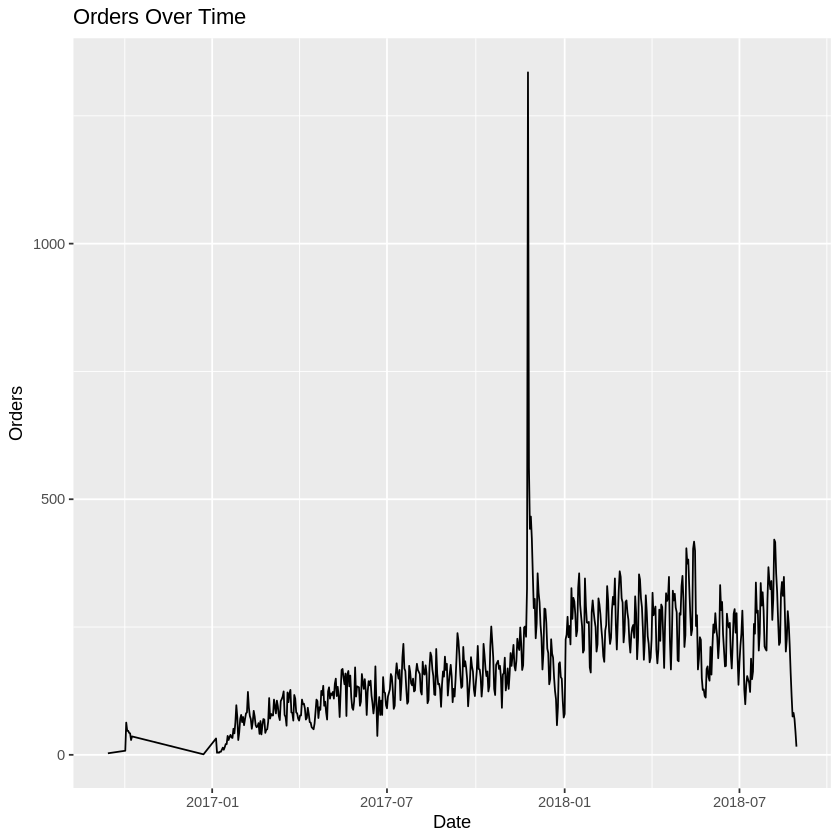

In [31]:
# Visual of orders over time
df%>%
  mutate(order_date = as.Date(order_purchase_timestamp)) %>%
  count(order_date) %>%
  ggplot(aes(x = order_date, y = n)) +
  geom_line() +
  labs(title = "Orders Over Time", x = "Date", y = "Orders")

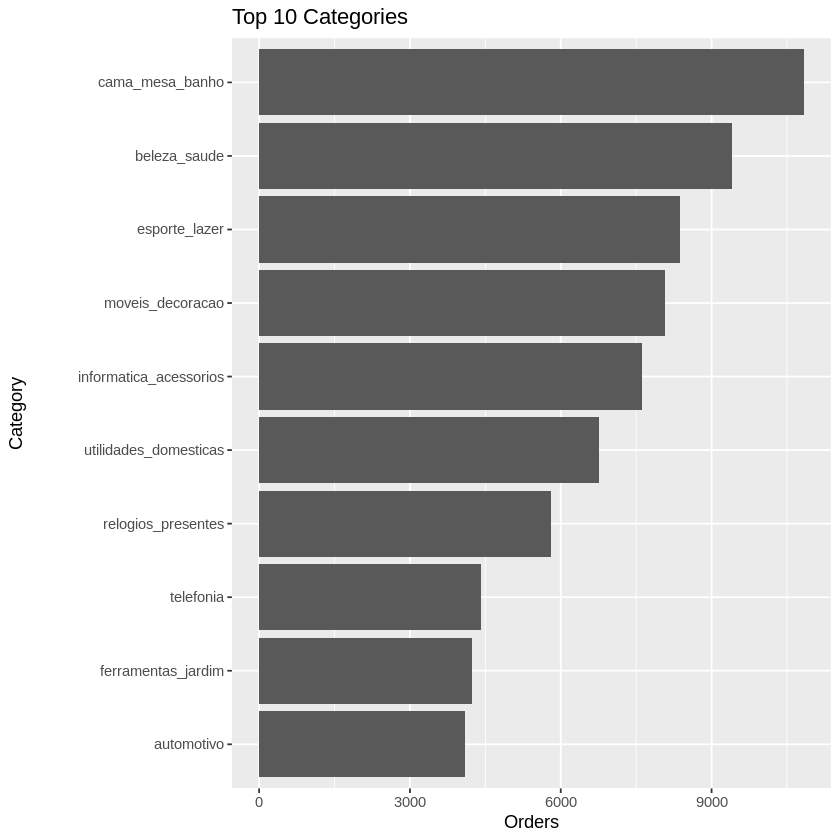

In [32]:
#Top Categories

df %>%
  count(product_category_name, sort = TRUE) %>%
  slice_head(n = 10) %>%
  ggplot(aes(x = reorder(product_category_name, n), y = n)) +
  geom_col() +
  coord_flip() +
  labs(title = "Top 10 Categories", x = "Category", y = "Orders")

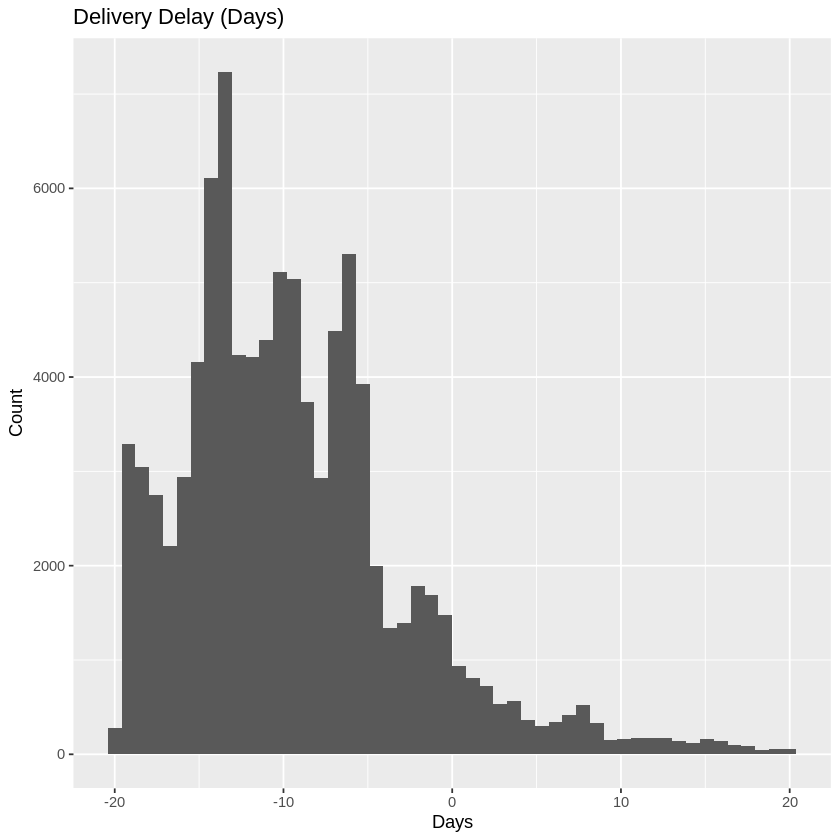

In [33]:
#Delivery Delay Histogram

df %>%
  filter(!is.na(delivery_delay_days),
         delivery_delay_days > -20,
         delivery_delay_days < 20) %>%
  ggplot(aes(x = delivery_delay_days)) +
  geom_histogram(bins = 50) +
  labs(title = "Delivery Delay (Days)", x = "Days", y = "Count")

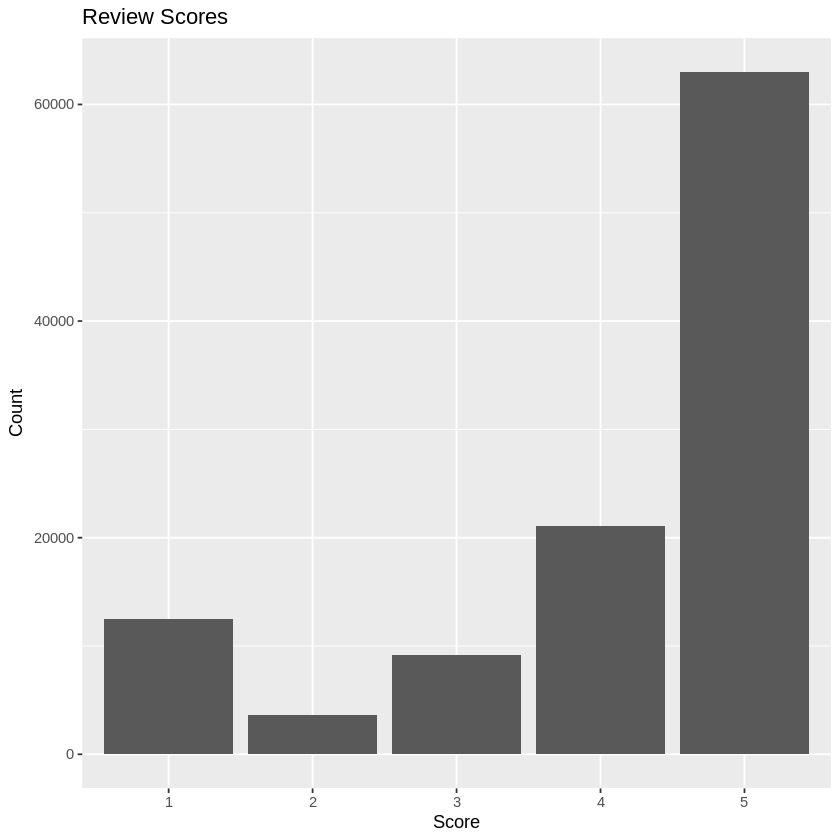

In [34]:
#Review Scores
df%>%
  ggplot(aes(x = factor(review_score))) +
  geom_bar() +
  labs(title = "Review Scores", x = "Score", y = "Count")

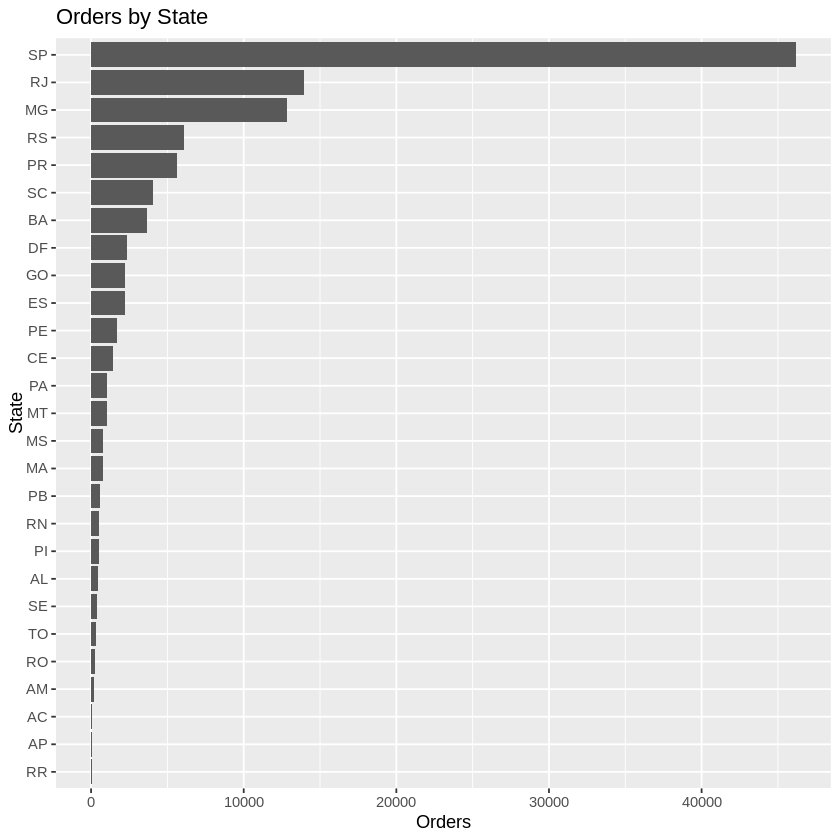

In [35]:
#Orders by State

df %>%
  count(customer_state, sort = TRUE) %>%
  ggplot(aes(x = reorder(customer_state, n), y = n)) +
  geom_col() +
  coord_flip() +
  labs(title = "Orders by State", x = "State", y = "Orders")

In [36]:
cat("==== SUMMARY ====\n")

cat("Total Orders:", nrow(df), "\n")

cat("Average Delivery Delay (days):",
    mean(df$delivery_delay_days, na.rm = TRUE), "\n")

cat("Average Review Score:",
    mean(df$review_score, na.rm = TRUE), "\n")

cat("Top State:",
    df%>% count(customer_state, sort = TRUE) %>% slice(1) %>% pull(customer_state),
    "\n")

cat("Top Category:",
    df%>% count(product_category_name, sort = TRUE) %>% slice(1) %>% pull(product_category_name),
    "\n")

==== SUMMARY ====
Total Orders: 109369 
Average Delivery Delay (days): -11.36816 
Average Review Score: 4.082345 
Top State: SP 
Top Category: cama_mesa_banho 
